# Global Fit of Impulses
This notebook performs a global fit of experimental PAZO curves under Paired-Pulse Facilitation (PPF) conditions across different pulse interval times ($t_{off}$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from scipy.optimize import curve_fit
from functions_general import *
%matplotlib widget


## Obtain Data

In this section, we load the preprocessed experimental data for different $t_{off}$ intervals (ranging from 2000 ms to 100000 ms). We set up the laser pulse timings (impulses) for each interval and define dynamic downsampling factors. The time, intensity, and laser power vectors are extracted and prepared for global fitting.

In [2]:
plt.close('all')

t_off_vector = [2000, 5000, 10000, 20000, 50000, 100000]

input_filenames = [
    'PPF_I20_500msON_2000msOFF_preprocessed_data',
    'PPF_I20_500msON_5000msOFF_preprocessed_data',
    'PPF_I20_500msON_10000msOFF_preprocessed_data',
    'PPF_I20_500msON_20000msOFF_preprocessed_data',
    'PPF_I20_500msON_50000msOFF_preprocessed_data',
    'PPF_I20_500msON_100000msOFF_preprocessed_data'
]

impulses_dict = {
    2000:   [(1.0724, 1.5696, 1.0), (3.5728, 4.1064, 1.0)],
    5000:   [(1.0742, 1.5785, 1.0), (6.5376, 7.0879, 1.0)],
    10000:  [(1.0795, 1.5790, 1.0), (11.5752, 12.0772, 1.0)],
    20000:  [(1.0708, 1.5749, 1.0), (21.5524, 22.0983, 1.0)],
    50000:  [(1.0770, 1.5744, 1.0), (51.5589, 52.1131, 1.0)],
    100000: [(1.0489, 1.571051, 1.0), (101.5567, 102.079023, 1.0)]
}

buffer_time_s = 2
buffer_time_s_before = 0.1

downsampling_factors_dict = {
    2000:   4,
    5000:   4,
    10000:  4,
    20000:  8,
    50000:  16,
    100000: 24
}

time_list = []
intensity_list = []
power_list = []

for t_off, filename in zip(t_off_vector, input_filenames):
    path_file = fr'./Input data for fitting/Impulses_PPF/{filename}.txt'
    data = pd.read_csv(path_file, sep='\t') 
    t_data = data.iloc[:, 0].to_numpy()
    i_data = data.iloc[:, 1].to_numpy()
    
    laser_power_full = np.zeros(len(t_data))
    laser_power_full = add_pulses(impulses_dict[t_off], t_data, laser_power_full)

    first_pulse_start = impulses_dict[t_off][0][0]

    # Create high-resolution mask around the pulse intervals
    mask_high_res = (t_data <= first_pulse_start)
    for (t_start, t_end, amp) in impulses_dict[t_off]:
        mask_high_res |= (t_data >= t_start - buffer_time_s_before) & (t_data <= t_end + buffer_time_s)
    
    current_downsample_factor = downsampling_factors_dict[t_off]
    
    # Create low-resolution mask for remaining regions
    indices = np.arange(len(t_data))
    mask_low_res = (~mask_high_res) & (indices % current_downsample_factor == 0)
    
    final_mask = mask_high_res | mask_low_res
    
    time_list.append(t_data[final_mask])
    intensity_list.append(i_data[final_mask])
    power_list.append(laser_power_full[final_mask])
    
    print(f"t_off {t_off}ms (Factor {current_downsample_factor}x): Original points = {len(t_data)} -> Filtered = {len(time_list[-1])}")

print(f"Prepared {len(intensity_list)} curves for global fitting.")

t_off 2000ms (Factor 4x): Original points = 1892 -> Filtered = 587
t_off 5000ms (Factor 4x): Original points = 2043 -> Filtered = 626
t_off 10000ms (Factor 4x): Original points = 2287 -> Filtered = 686
t_off 20000ms (Factor 8x): Original points = 2730 -> Filtered = 476
t_off 50000ms (Factor 16x): Original points = 4081 -> Filtered = 398
t_off 100000ms (Factor 24x): Original points = 6761 -> Filtered = 430
Prepared 6 curves for global fitting.


### Visualize Pre-Fit Data

We plot the downsampled experimental intensity curves along with their corresponding laser pulse shapes to visually confirm the data alignment and pulse timings.

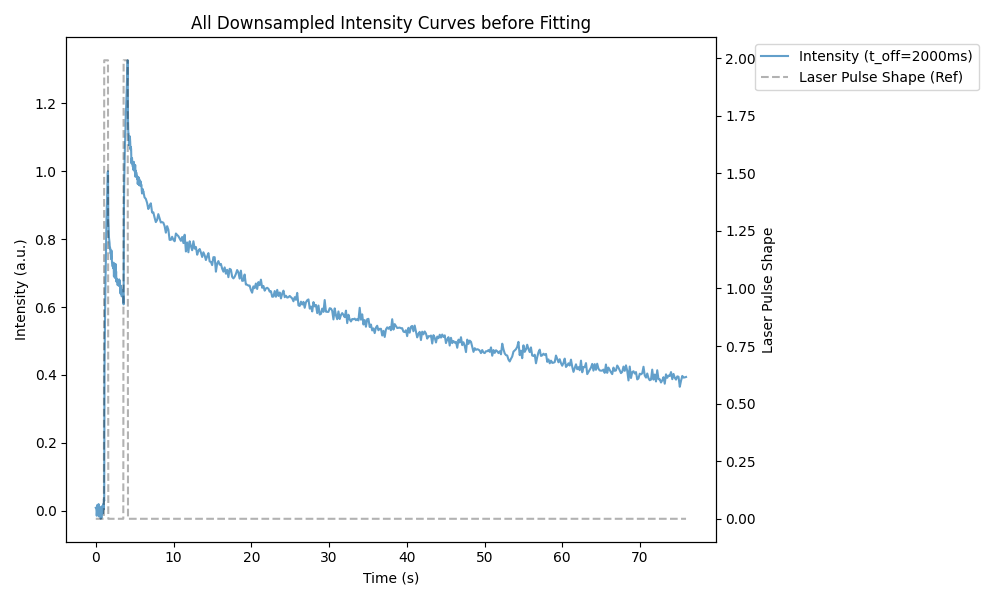

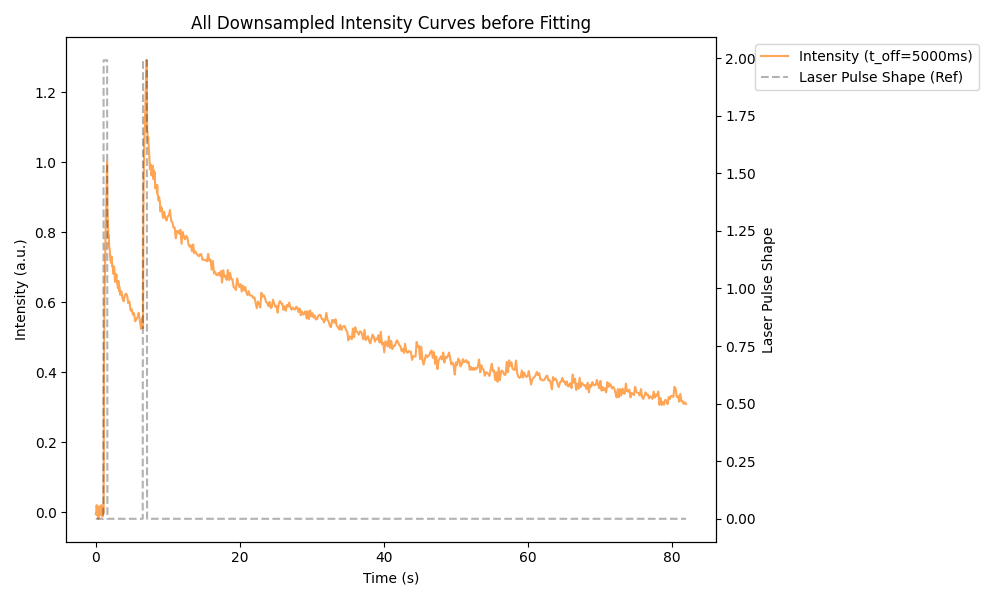

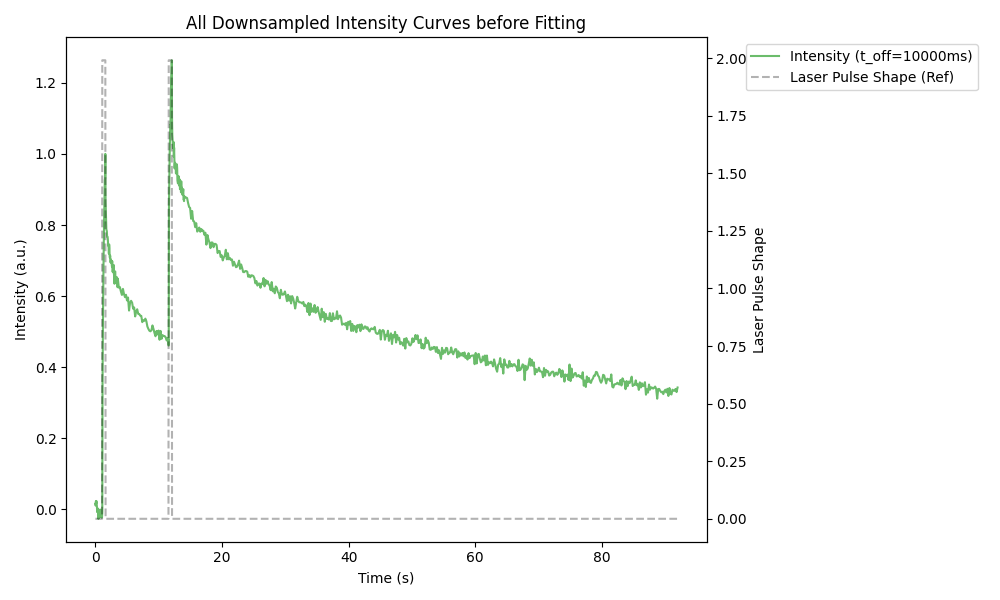

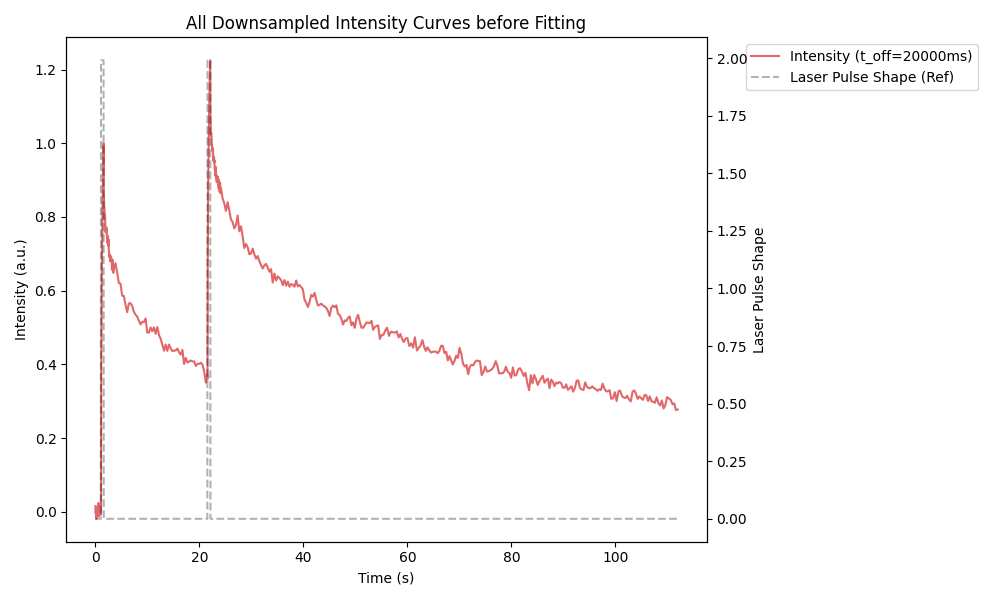

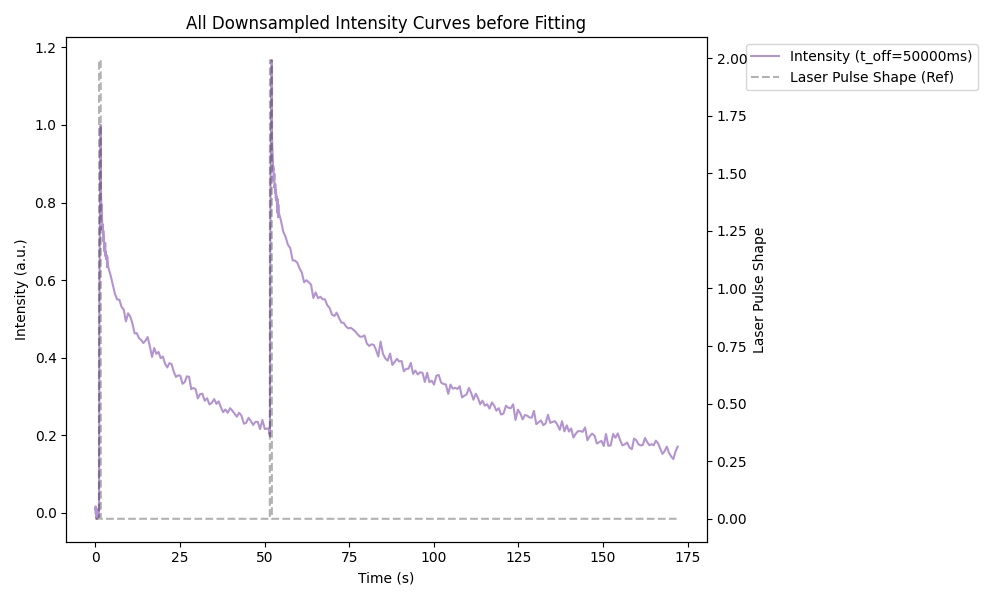

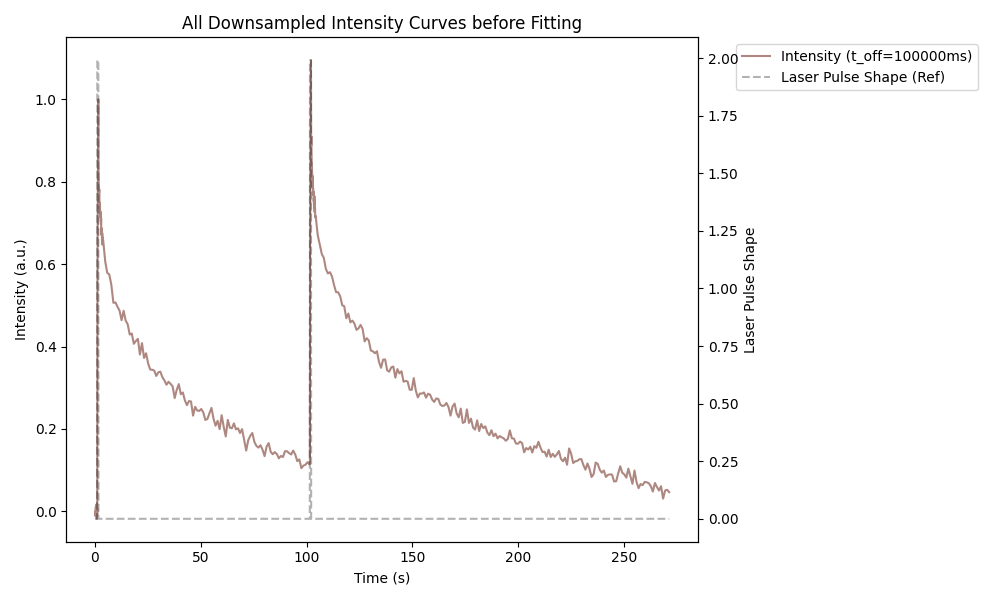

In [3]:
for i in range(len(intensity_list)):
    fig, ax1 = plt.subplots(figsize=(10, 6))

    prop_cycle = plt.rcParams['axes.prop_cycle']
    colors = prop_cycle.by_key()['color']
    t_plot = time_list[i]
    i_plot = intensity_list[i]
    t_off_val = t_off_vector[i]
    color = colors[i % len(colors)]
    
    ax1.plot(t_plot, i_plot, '-', label=f'Intensity (t_off={t_off_val}ms)', alpha=0.7, color=color)

    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Intensity (a.u.)')
    ax1.set_title('All Downsampled Intensity Curves before Fitting')

    ax2 = ax1.twinx()
    p_ref = power_list[i]
    t_ref = time_list[i]

    max_p = np.max(p_ref) if np.max(p_ref) > 0 else 1
    p_normalized = p_ref / max_p
    visualization_scale = np.max(np.concatenate(intensity_list)) * 1.5

    ax2.plot(t_ref, p_normalized * visualization_scale, 'k--', label='Laser Pulse Shape (Ref)', alpha=0.3)
    ax2.set_ylabel('Laser Pulse Shape', color='k')
    ax2.tick_params('y', colors='k')

    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc='upper left', bbox_to_anchor=(1.05, 1))

    fig.tight_layout()
    plt.show()

## 3. Global Fit Configuration

We define the initial values (`init_val_dict`), the parameters to fit (`var_dict`), and set whether parameters are global (shared across curves) or local using `fit_global`.

In [4]:
init_val_dict = {
    'kp1': 9.8846,
    'kd1': 0.901137,
    'Imax1': 0.364601,
    'kp2': 1.325087,
    'kd2': 0.012363,
    'Imax2': 1.217128
}

# 1 = fit parameter, 0 = keep fixed at initial value
var_dict = {
    'kp1': 1, 'kd1': 1, 'Imax1': 1,
    'kp2': 1, 'kd2': 1, 'Imax2': 1
}

# 1 = global parameter (shared), 0 = local parameter (independent)
fit_global = {
    'kp1': 1,
    'kd1': 1,
    'Imax1': 1,
    'kp2': 1,
    'kd2': 1,
    'Imax2': 1
}

## 4. Run the Fit

We instantiate the `GlobalFitManager` with our double rate dict model, apply parameters, and run the optimization. The resulting values and $R^2$ scores are printed.

In [5]:
global_fitter = GlobalFitManager(model_fit_double_rate_dict, time_list, power_list, intensity_list)
global_fitter.setup_parameters(init_val_dict, var_dict, fit_global)

results_df = global_fitter.run_fit()

if results_df is not None:
    # Replace power density column with t_off in final DataFrame
    results_df.insert(0, 't_off (ms)', t_off_vector)
    print("Global Fit Results:")
    print(results_df)

    r2_array = global_fitter.calculate_R2(results_df)
    print("\nR2 error vector:")
    print(r2_array)

Starting global fit with 6 free parameters...
Fit completed successfully.
Global Fit Results:
   t_off (ms)  Curve_Index        kp1       kd1    Imax1       kp2      kd2  \
0        2000            0  11.763144  0.701348  0.40148  1.178548  0.01274   
1        5000            1  11.763144  0.701348  0.40148  1.178548  0.01274   
2       10000            2  11.763144  0.701348  0.40148  1.178548  0.01274   
3       20000            3  11.763144  0.701348  0.40148  1.178548  0.01274   
4       50000            4  11.763144  0.701348  0.40148  1.178548  0.01274   
5      100000            5  11.763144  0.701348  0.40148  1.178548  0.01274   

      Imax2  
0  1.138622  
1  1.138622  
2  1.138622  
3  1.138622  
4  1.138622  
5  1.138622  

R2 error vector:
[0.97038891 0.97201792 0.97369228 0.97858264 0.97540397 0.97959025]


### Export Optimized Parameters

We extract the optimized parameters from the final row as a dictionary format.

In [6]:
if results_df is not None:
    last_params_dict = results_df.iloc[-1].to_dict()
    for label, value in last_params_dict.items():
        print(f"'{label}': {value},")

't_off (ms)': 100000.0,
'Curve_Index': 5.0,
'kp1': 11.763144112194786,
'kd1': 0.7013477009627074,
'Imax1': 0.40148033591868976,
'kp2': 1.1785483276316535,
'kd2': 0.012739856172623552,
'Imax2': 1.13862207595484,


## 5. Visualize Results

Finally, we plot the fit results. First, we plot all curves on a single plot to visualize the global fit, and then we plot each curve on its own individual plot.

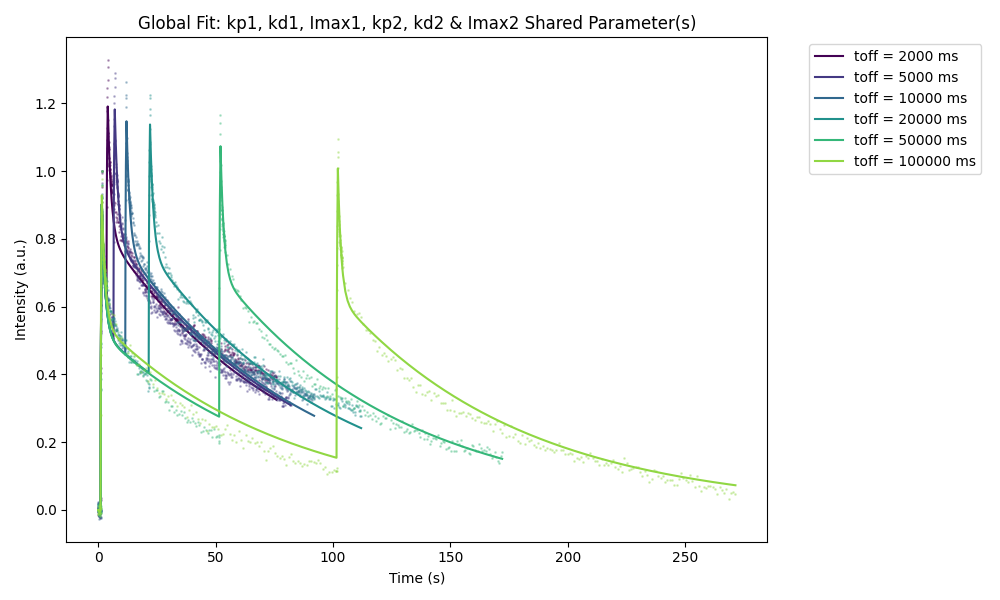

In [7]:
global_fitted_params = [
    k for k in init_val_dict.keys() 
    if var_dict.get(k, 0) == 1 and fit_global.get(k, 0) == 1
]

if global_fitted_params:
    if len(global_fitted_params) > 1:
        shared_params_str = ', '.join(global_fitted_params[:-1]) + ' & ' + global_fitted_params[-1]
    else:
        shared_params_str = global_fitted_params[0]
    dynamic_title = f'Global Fit: {shared_params_str} Shared Parameter(s)'
else:
    dynamic_title = 'Global Fit: Local/Independent Curves'

if results_df is not None:
    plt.figure(figsize=(10, 6))
    
    for i in range(len(time_list)):
        t = time_list[i]
        p = power_list[i]
        real_intensity = intensity_list[i]
        t_off_val = t_off_vector[i]
        
        best_params = results_df.iloc[i].to_dict()
        fit_intensity, _, _ = model_fit_double_rate_dict(t, p, best_params)
        
        color = plt.cm.viridis(i / len(time_list))
        plt.plot(t, real_intensity, '.', markersize=2, alpha=0.3, color=color)
        plt.plot(t, fit_intensity, '-', linewidth=1.5, label=f'toff = {t_off_val} ms', color=color)

    plt.xlabel('Time (s)')
    plt.ylabel('Intensity (a.u.)')
    plt.title(dynamic_title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

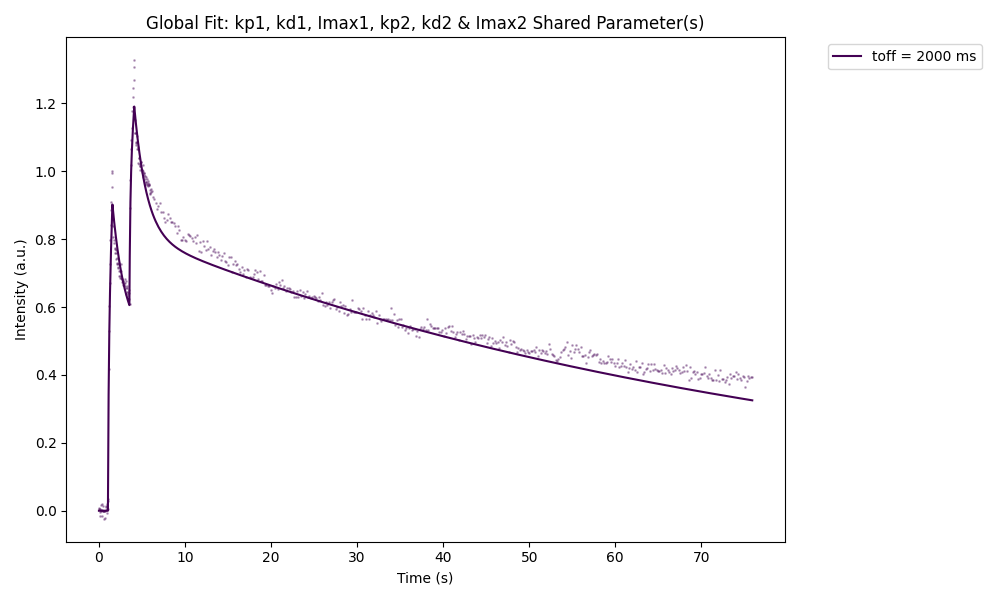

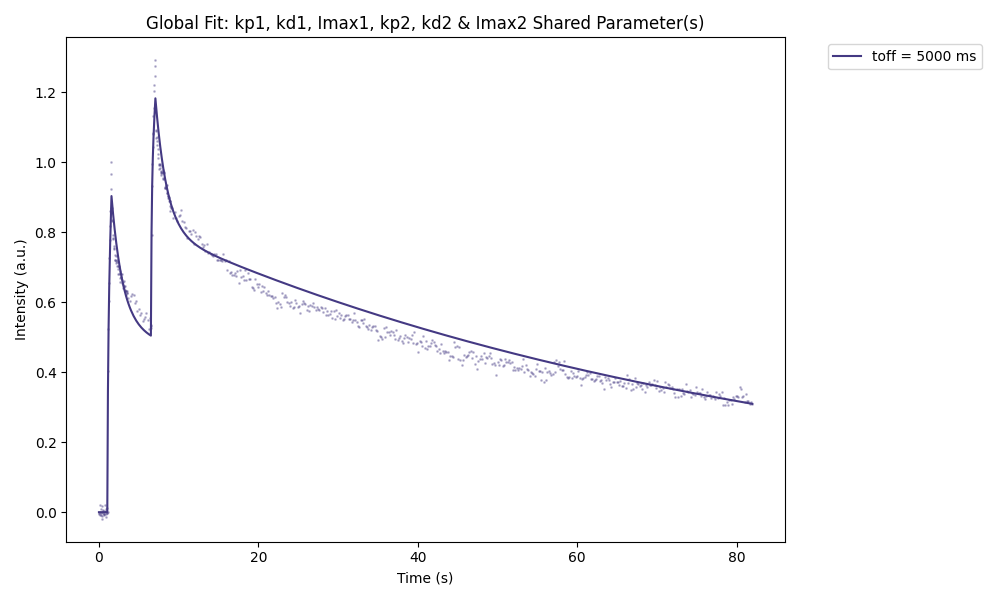

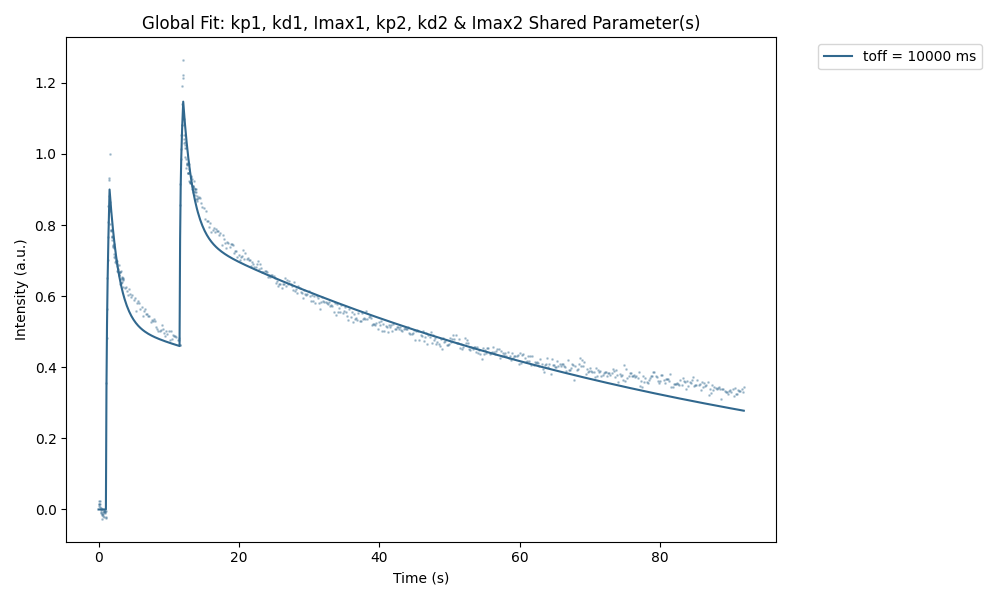

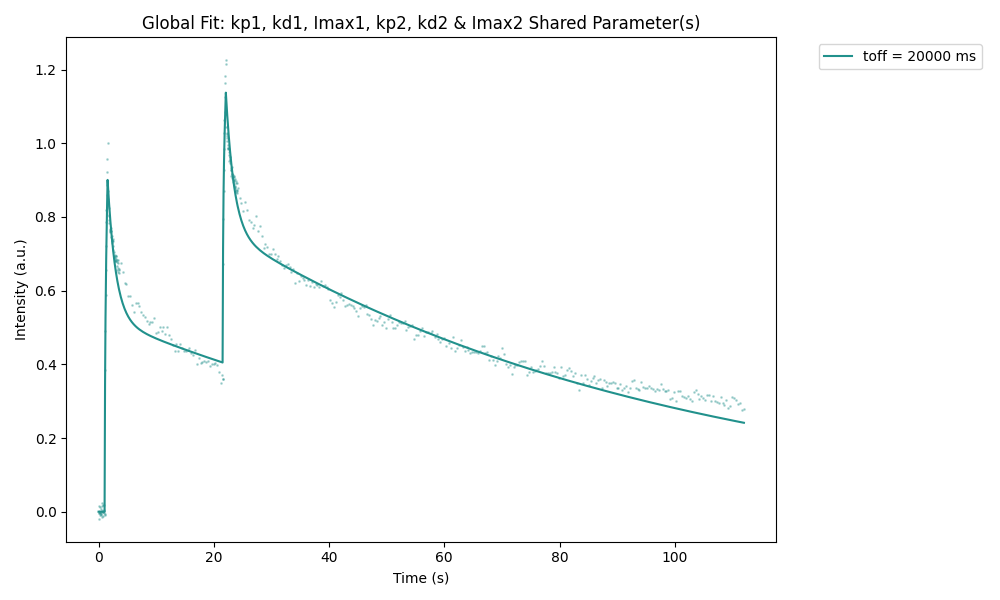

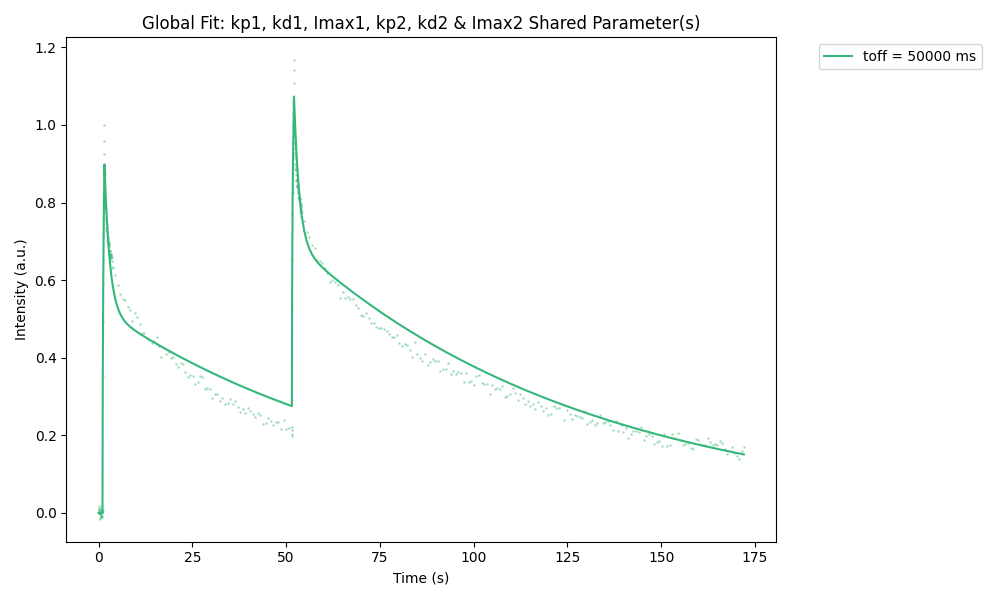

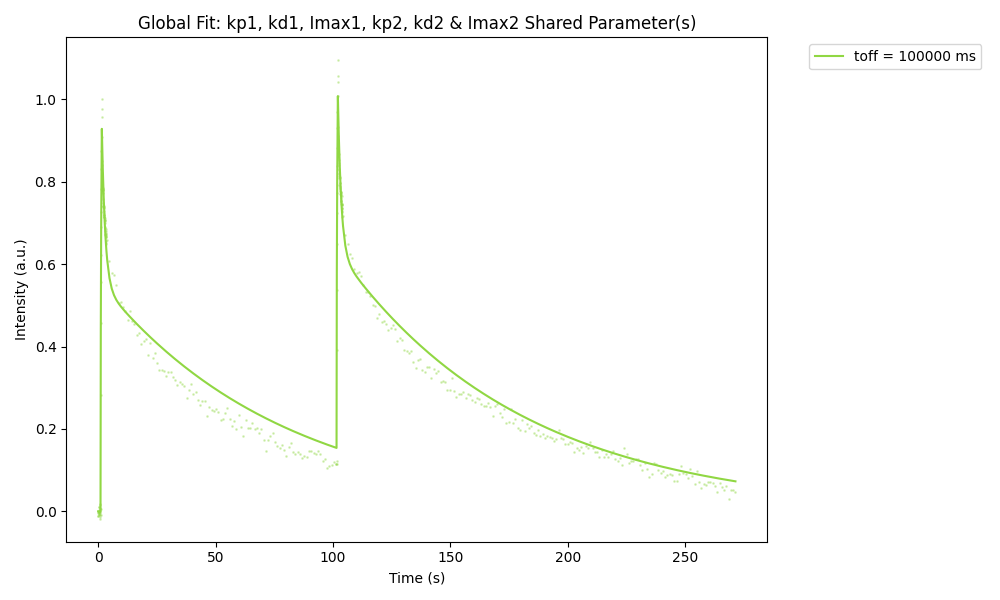

In [8]:
if results_df is not None:
    for i in range(len(time_list)):
        plt.figure(figsize=(10, 6))
        t = time_list[i]
        p = power_list[i]
        real_intensity = intensity_list[i]
        t_off_val = t_off_vector[i]
        
        best_params = results_df.iloc[i].to_dict()
        fit_intensity, _, _ = model_fit_double_rate_dict(t, p, best_params)
        
        color = plt.cm.viridis(i / len(time_list))
        plt.plot(t, real_intensity, '.', markersize=2, alpha=0.3, color=color)
        plt.plot(t, fit_intensity, '-', linewidth=1.5, label=f'toff = {t_off_val} ms', color=color)

        plt.xlabel('Time (s)')
        plt.ylabel('Intensity (a.u.)')
        plt.title(dynamic_title)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()